# CASM Calibration + Beamforming Walkthrough

End-to-end tutorial: from antenna positions in CAsMan all the way to int8 beamforming weights ready for upload to the online beamformer.

**Companion notebook**: `casm_pulsar_search_walkthrough.ipynb` covers beam-dump -> filterbank -> pulsar search.

**Data used in this run**:
- Visibilities: auto-discovered from `/mnt` for a 10-minute Sun-transit window on 2026-05-16
- Cal source: Sun (today's daytime obs)
- Pre-baked production-style cal: `/home/casm/scratch/bf_cal_validation_2026_05_15/cal/cal_sun_2026_05_14_thr5_22ant.h5`

**Convention reminders** (baked into defaults below):
- Freq order: descending (CASM native, 484.375 -> 390.625 MHz)
- Fringe-stop sign: `-1`
- RFI mask is optional - drop-bad-channels (SVD threshold = 5) handles most cases


## Setup

Activate the refactor-tower venv before launching Jupyter, so this notebook picks up the right `casm_io`, `casm_vis_analysis`, `casm_calibrator`, `casm_imaging`, and `bf_weights_generator`.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 6)

# Set to a Path if you want to save figures; leave None for inline-only
SAVE_DIR = None

# Reference paths
ANTENNA_CSV = '/home/casm/software/dev/antenna_layouts/casm_antenna_layout_2026-05-15.csv'
CAL_H5 = '/home/casm/scratch/bf_cal_validation_2026_05_15/cal/cal_sun_2026_05_14_thr5_22ant.h5'
INT8_WEIGHTS = '/home/casm/software/dev/GOOD_BF_IMAGES/weights_b0329_2026_05_16_512beams_int8.h5'
DATA_ROOT = '/mnt'
DATA_DIR_64ANT = '/mnt/nvme4/data/casm/visibilities_64ant'
FORMAT_NAME = 'layout_64ant'


## section 1 - Antenna layout from CAsMan

The antenna layout has two stages:
1. **CAsMan -> wiring CSV**: `casm-sync-wiring --apply` reads chassis/slot/ADC connections from CAsMan and writes `casm_wiring.csv`.
2. **Wiring CSV -> consumer CSV**: `casm-build-layout --check-casman` joins wiring with physical positions to produce the file consumed by `AntennaMapping.load`.

**Conflict policy**: CAsMan wins. Hand-edits to `casm_wiring.csv` don't survive `--apply` - put overrides in `casm_wiring_overrides.csv` (rows of `add` / `disable` / `replace` keyed by `(chassis, slot, adc)`).

Below we just load the consumer CSV. Run the two CLI commands if you want to regenerate from CAsMan.


In [2]:
from casm_io.correlator import AntennaMapping, load_format

ant = AntennaMapping.load(ANTENNA_CSV)
aids = sorted(ant.active_antennas())
pkts = np.array([ant.packet_index(a) for a in aids])
pos  = ant.get_positions()
pos_active = pos[pkts]

print(f'active antennas: {len(aids)}')
print(f'antenna IDs:     {aids}')
print(f'positions shape: {pos_active.shape}  (ENU, meters)')
print(f'extent (E,N,U): {np.ptp(pos_active, axis=0).round(1).tolist()} m')


active antennas: 23
antenna IDs:     [1, 3, 7, 9, 10, 12, 14, 15, 18, 19, 21, 22, 23, 24, 30, 32, 33, 36, 38, 40, 42, 44, 45]
positions shape: (23, 3)  (ENU, meters)
extent (E,N,U): [2.0, 10.5, 0.0] m


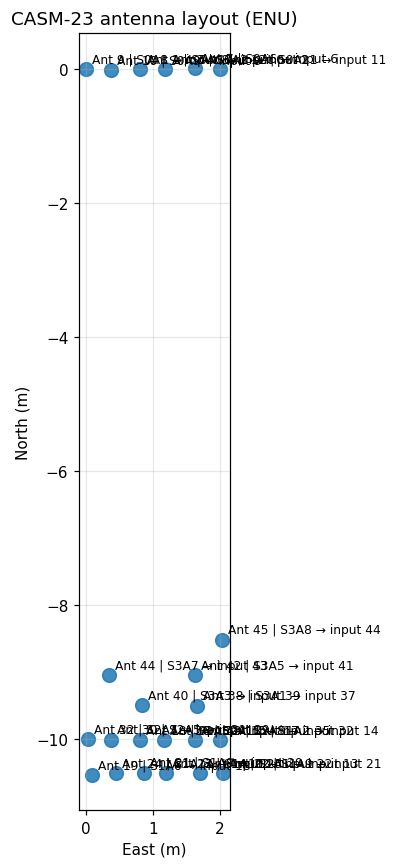

In [3]:
# Plot antenna positions in ENU
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pos_active[:, 0], pos_active[:, 1], s=80, c='C0', alpha=0.85)
for aid, p in zip(aids, pos_active):
    ax.annotate(ant.format_antenna(aid), (p[0], p[1]),
                xytext=(4, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')
ax.set_title(f'CASM-{len(aids)} antenna layout (ENU)')
ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## section 2 - Load visibilities

**Default path: auto-discovery by time range** in local Pacific time. `read_visibilities` scans `data_root` for matching `visibilities_*` dirs and stitches if the time range spans multiple obs.

For a single known obs dir, `VisibilityReader` is the lower-level option (shown below the default).


In [4]:
from casm_io.correlator import read_visibilities

fmt = load_format(FORMAT_NAME)

# DEFAULT: auto-discovery by time range (local PT). Short 10-min window for a fast demo.
data = read_visibilities(
    time_start='2026-05-16 12:00:00',
    time_end='2026-05-16 12:10:00',
    time_tz='America/Los_Angeles',
    data_root=DATA_ROOT,
    fmt=fmt,
    verbose=True,
)
vis       = data.vis        # (T, F, n_bl) complex64
freq_mhz  = data.freq_mhz   # (F,)  descending native
time_unix = data.time_unix  # (T,)
print(f'vis shape: {vis.shape}   dtype: {vis.dtype}')
print(f'freq range: {freq_mhz[0]:.3f} -> {freq_mhz[-1]:.3f} MHz  ({len(freq_mhz)} chans)')
print(f'T_obs: {(time_unix[-1] - time_unix[0]) / 60:.1f} min')


Requested (UTC): 2026-05-16 19:00:00 UTC -> 2026-05-16 19:10:00 UTC
Requested (PT):  2026-05-16 12:00:00 PDT -> 2026-05-16 12:10:00 PDT
Requested (America/Los_Angeles): 2026-05-16 12:00:00 -> 2026-05-16 12:10:00


Scanning /mnt ...
  Found: visibilities_256ant/
  Found: visibilities_64ant/
  Found: visibilities_64ant/
  visibilities_256ant/: 1 observations (2026-03-04-08:55:00 -> 2026-03-04-08:55:00)
  visibilities_64ant/: 47 observations (2026-03-03-05:20:00 -> 2026-04-29-19:40:39)
  visibilities_64ant/: 11 observations (2026-05-02-12:22:04 -> 2026-05-17-00:09:45)

Matching observations: 2
  [1] 2026-05-16-17:56:49  (1 files)
      UTC: 2026-05-16 17:56:49 UTC -> 2026-05-16 19:10:07 UTC
      PT:  2026-05-16 10:56:49 PDT -> 2026-05-16 12:10:07 PDT
  [2] 2026-05-16-18:41:34  (5 files)
      UTC: 2026-05-16 18:41:34 UTC -> 2026-05-17 00:48:04 UTC
      PT:  2026-05-16 11:41:34 PDT -> 2026-05-16 17:48:04 PDT

Reading 2026-05-16-17:56:49 (2026-05-16 19:00:00 UTC -> 2026-05-16 19:10:00 UTC) ...
Data span (UTC): 2026-05-16 17:56:49 UTC -> 2026-05-16 19:10:07 UTC
Data span (PT):  2026-05-16 10:56:49 PDT -> 2026-05-16 12:10:07 PDT
Files available: 1 (indices 0-0)
Reading integrations 28-32 from files 0

  2026-05-16-17:56:49.dat.0: ntime=20 (expected 32)
Output shape: (0, 3072, 8256) (complex64)
Frequency: 484.375 -> 390.656 MHz (descending)
Time samples: 0

Reading 2026-05-16-18:41:34 (2026-05-16 19:00:00 UTC -> 2026-05-16 19:10:00 UTC) ...
Data span (UTC): 2026-05-16 18:41:34 UTC -> 2026-05-17 00:48:04 UTC
Data span (PT):  2026-05-16 11:41:34 PDT -> 2026-05-16 17:48:04 PDT
Files available: 5 (indices 0-4)
Reading integrations 9-13 from files 0-0
  Reading files [==============================] 1/1 

Output shape: (4, 3072, 8256) (complex64)
Frequency: 484.375 -> 390.656 MHz (descending)
Time samples: 4



Final output shape: (4, 3072, 8256) (complex64)
Frequency: 484.375 -> 390.656 MHz (descending)
Time samples: 4
Time span (UTC): 2026-05-16 19:02:10 UTC -> 2026-05-16 19:09:03 UTC
Time span (PT):  2026-05-16 12:02:10 PDT -> 2026-05-16 12:09:03 PDT
vis shape: (4, 3072, 8256)   dtype: complex64
freq range: 484.375 -> 390.656 MHz  (3072 chans)
T_obs: 6.9 min


### Subset examples (any combination)

**A. Specific frequency range** (post-load slice - clearest):


In [5]:
mask_440_465 = (freq_mhz >= 440) & (freq_mhz <= 465)
vis_lb  = vis[:, mask_440_465, :]
freq_lb = freq_mhz[mask_440_465]
print(f'live-band subset: {vis_lb.shape}, {freq_lb[0]:.2f}-{freq_lb[-1]:.2f} MHz')


live-band subset: (4, 820, 8256), 465.00-440.00 MHz


**B. Specific channel indices**:

In [6]:
chans = np.arange(631, 1443)
vis_chan = vis[:, chans, :]
print(f'channel slice: {vis_chan.shape}')


channel slice: (4, 812, 8256)


**C. Specific ref + targets via the lower-level reader**:

In [7]:
from casm_io.correlator import VisibilityReader, discover_observations

# discover_observations scans a specific dir and returns dicts. Pick the
# longest overlapping obs (some same-day obs are shorter recovery dumps).
obs_list = discover_observations(DATA_DIR_64ANT, fmt=fmt)
target_start_unix = time_unix[0]
candidates = [o for o in obs_list if o['time_start'] <= target_start_unix <= o['time_end']]
candidates.sort(key=lambda o: -o['n_files'])
obs_record = candidates[0]
obs_base = obs_record['base_str']
obs_data_dir = obs_record['data_dir']    # parent dir; VisibilityReader takes the parent + base_str
print(f'using obs: {obs_base} ({obs_record["n_files"]} files)')

v = VisibilityReader(data_dir=obs_data_dir, base_str=obs_base, fmt=fmt)
ref = aids[10] if len(aids) > 10 else aids[0]
targets = aids[:5]
result = v.read(
    ref=ref,
    targets=targets,
    time_start='2026-05-16 12:00:00',
    time_end='2026-05-16 12:05:00',
    time_tz='America/Los_Angeles',
    verbose=False,
)
print(f'ref/target subset: {result.vis.shape}  (T, F, n_targets)')


using obs: 2026-05-16-18:41:34 (5 files)


ref/target subset: (2, 3072, 5)  (T, F, n_targets)


**D. Specific antenna pair via triu indexing**:

In [8]:
from casm_io.correlator.baselines import triu_flat_index

nsig = int(fmt.nsig)
i, j = 5, 12  # antenna packet indices (use ant.packet_index(aid))
bl_idx = triu_flat_index(nsig, min(i, j), max(i, j))
single_bl = vis[:, :, bl_idx]
print(f'single baseline (packet indices {i},{j}): {single_bl.shape}  (T, F) complex')


single baseline (packet indices 5,12): (4, 3072)  (T, F) complex


## section 3 - Inspect raw data

Three core diagnostic views:
1. **Autocorrelation power spectra** per SNAP - quick bandpass check
2. **Cross-correlation waterfall** (upper-triangle matrix) - full obs-vs-baseline picture
3. **Per-baseline `|V|`, `Re(V)`, `Im(V)`, `phase(V)`** - diagnose one baseline at a time

To plot we extract autocorrelations from the full-triangle `vis` for the active set.


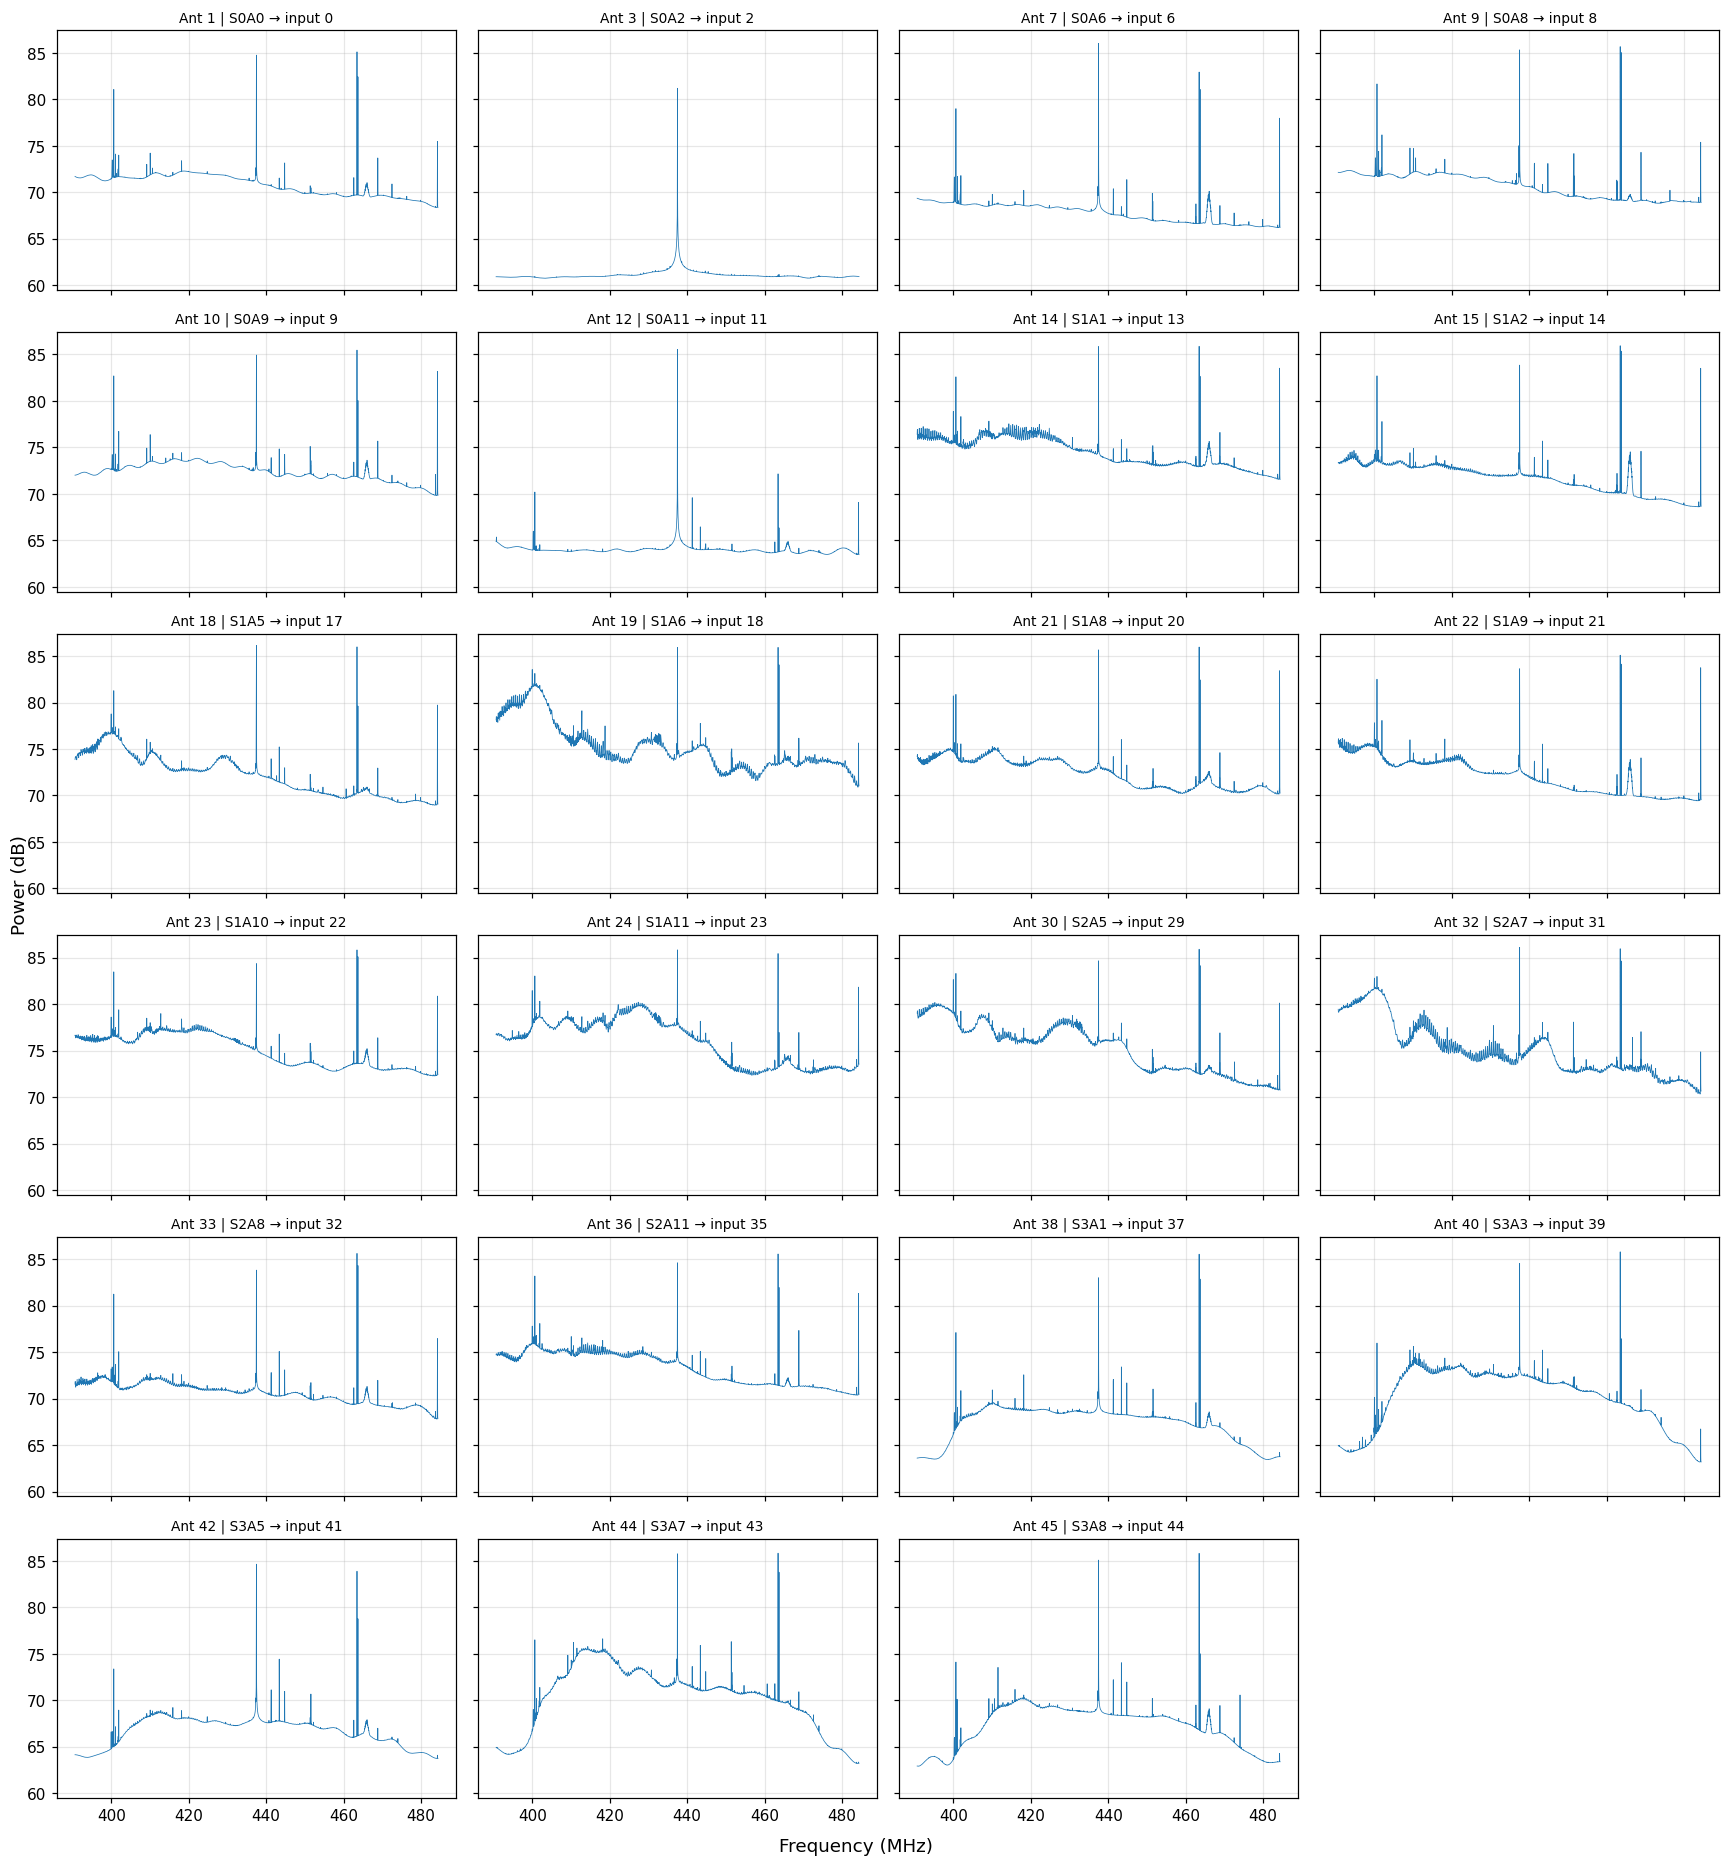

In [9]:
from casm_vis_analysis.plotting.autocorr import plot_autocorr

# Build (T, F, n_active) autocorr array by indexing diagonal triu entries.
auto_idx = np.array([triu_flat_index(nsig, p, p) for p in pkts])
vis_auto = vis[:, :, auto_idx]  # (T, F, n_active) complex (real part is power)

antenna_labels = [ant.format_antenna(a) for a in aids]
fig = plot_autocorr(vis_auto, freq_mhz, antenna_labels, time_avg=True, ncols=4)
plt.show()


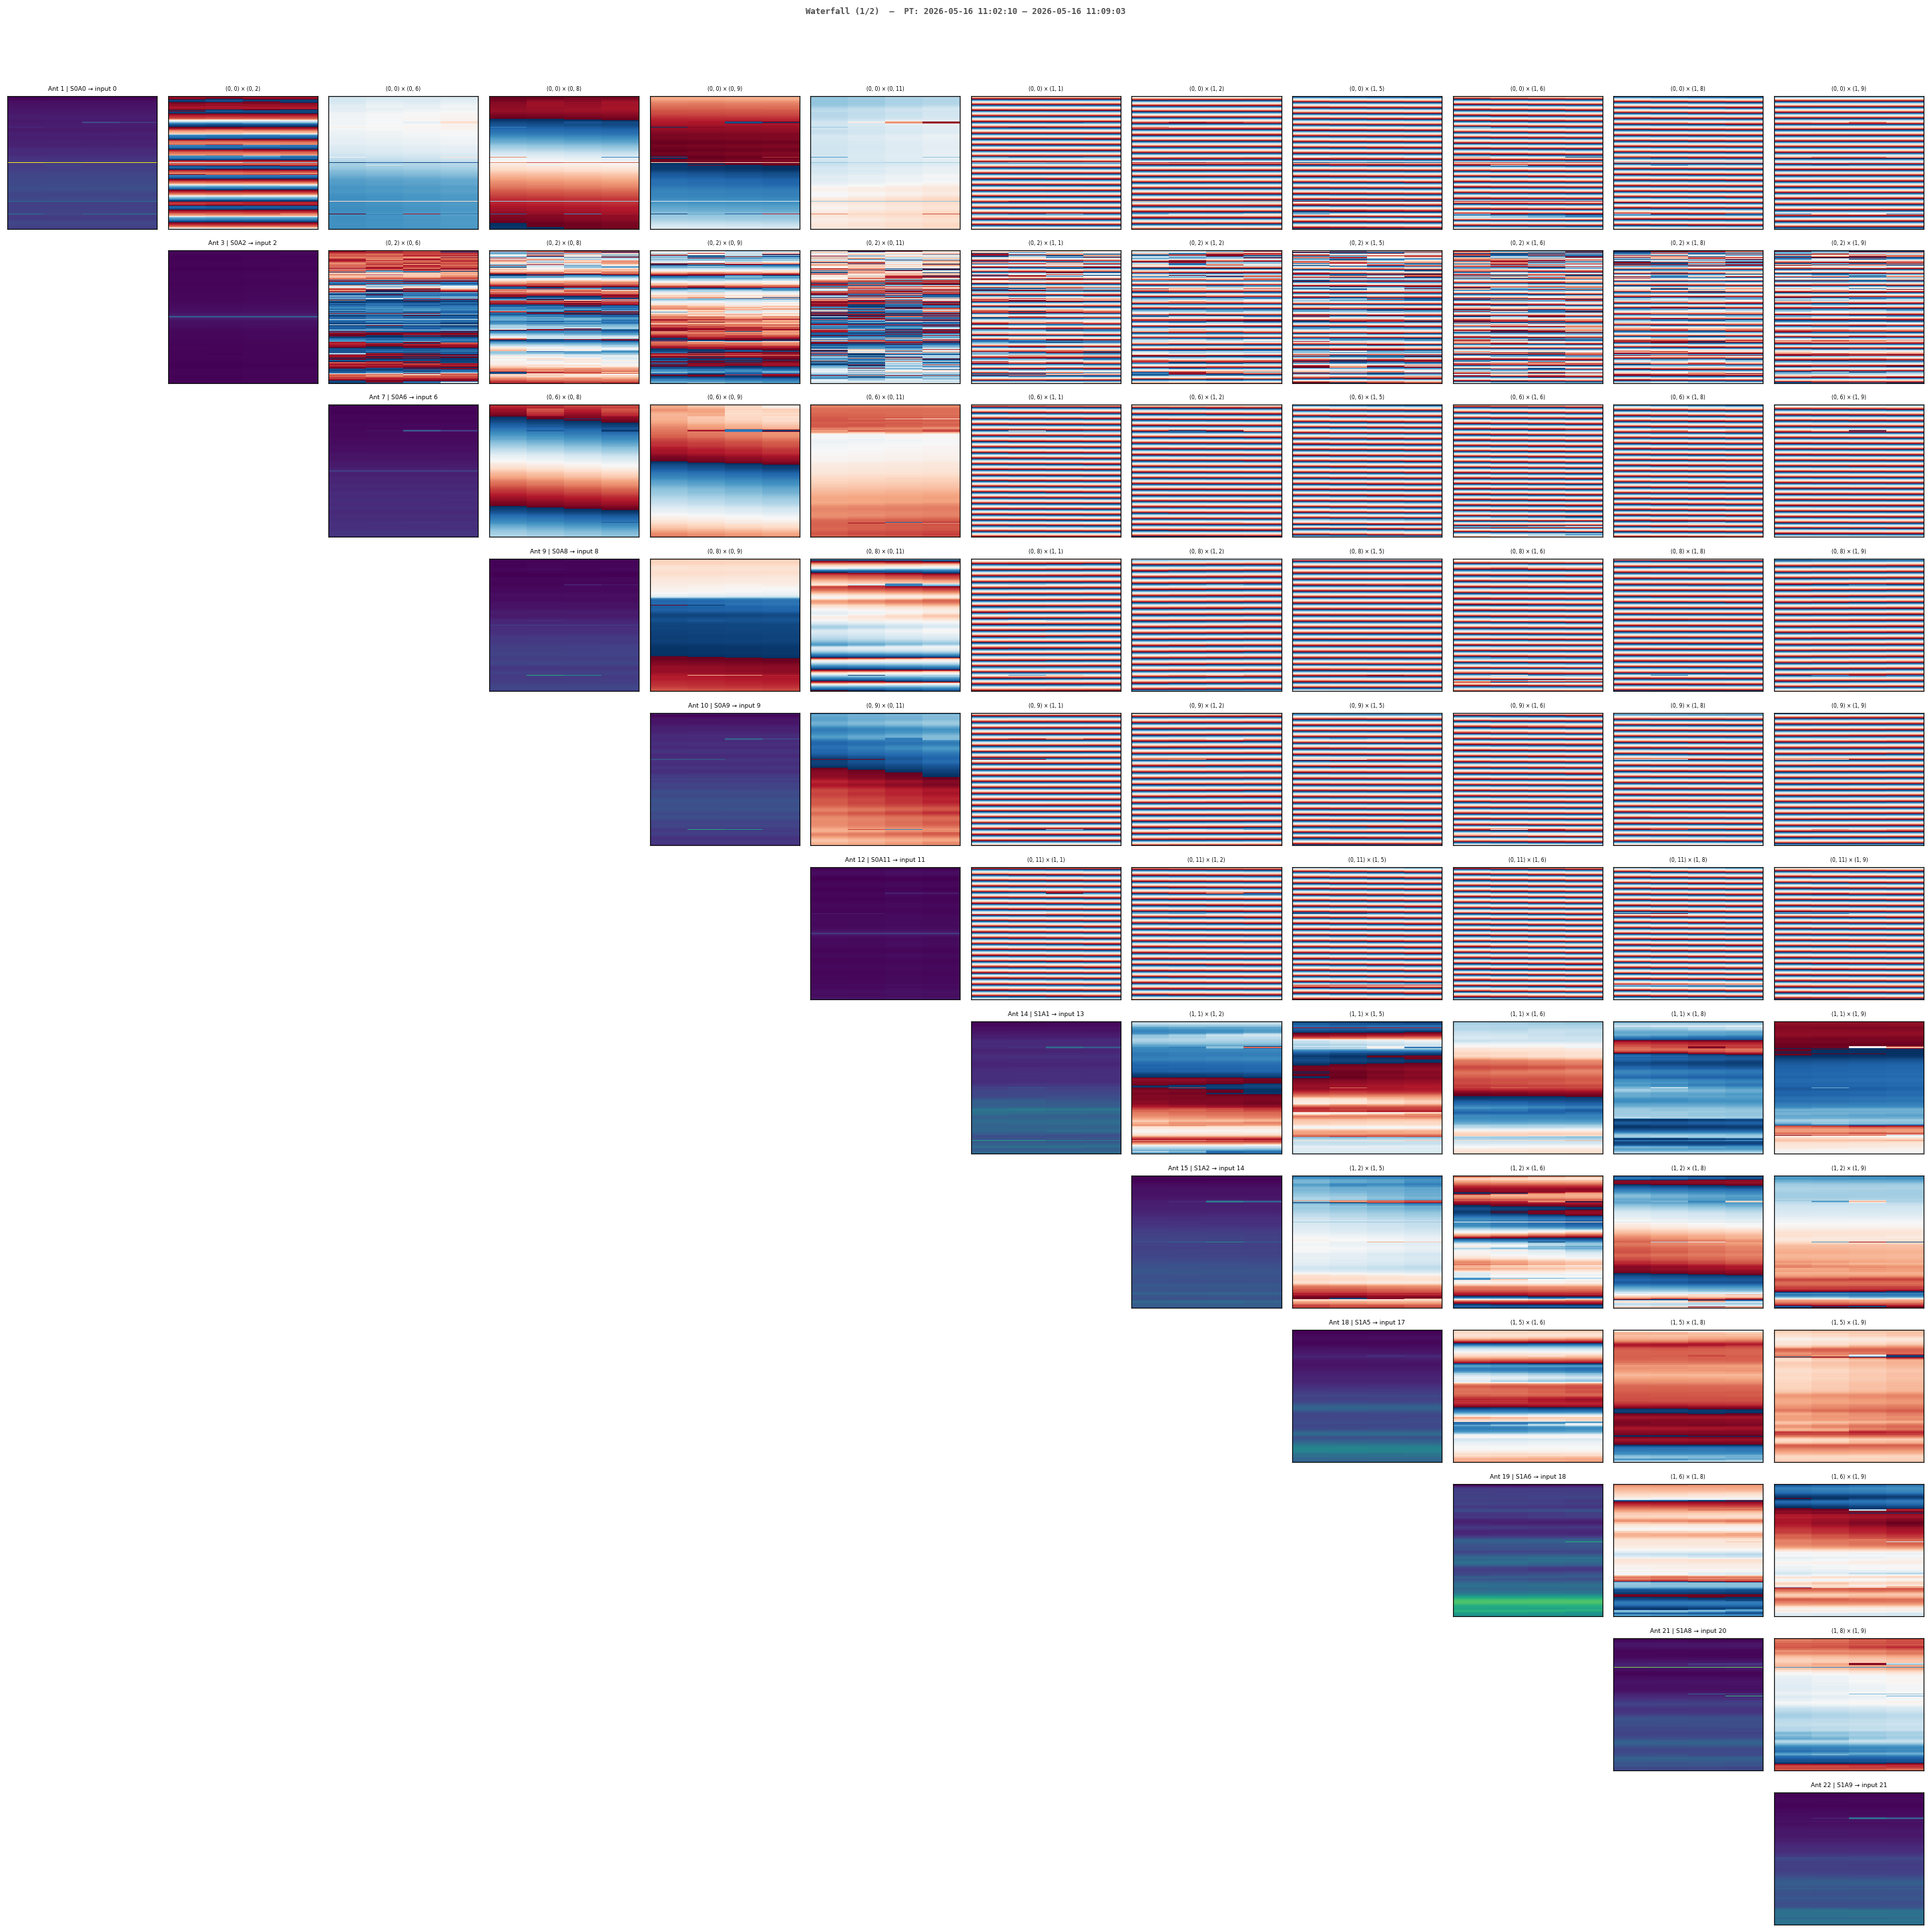

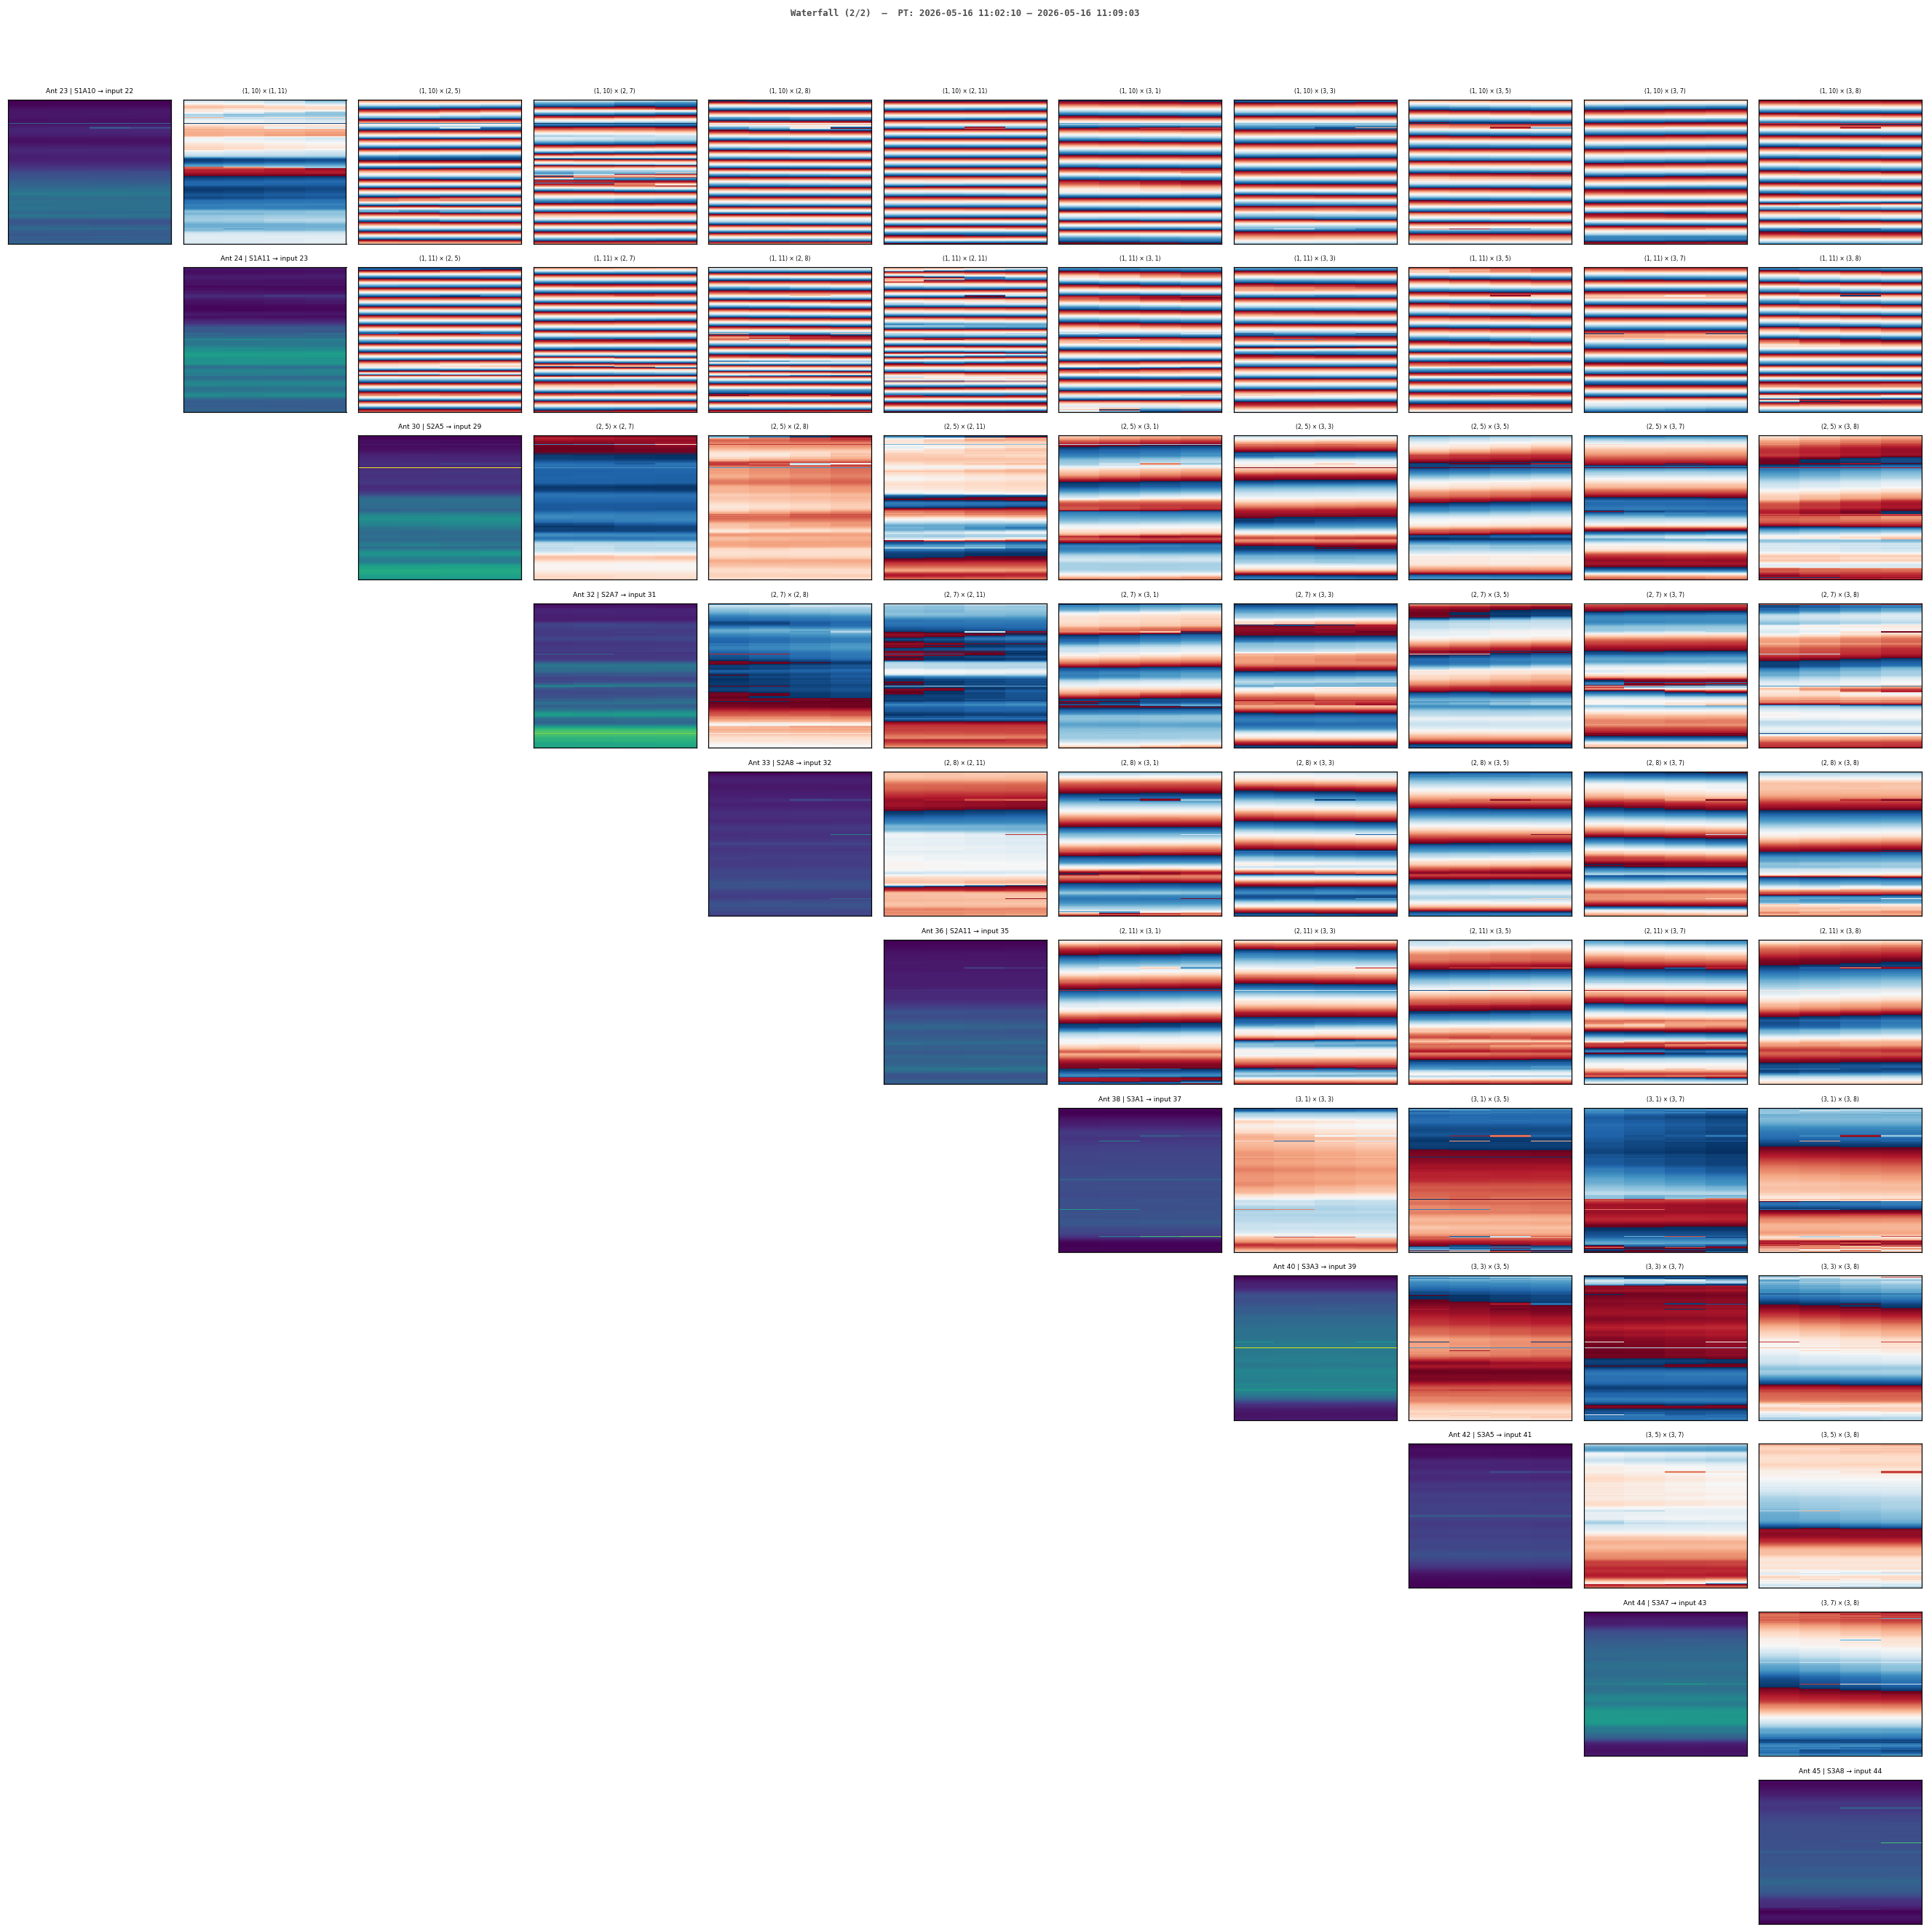

In [10]:
from casm_vis_analysis.plotting.waterfall import plot_waterfall

snap_adc_labels = [str(ant.snap_adc(a)) for a in aids]
figs = plot_waterfall(
    vis, freq_mhz, time_unix,
    nsig=nsig, packet_indices=pkts,
    antenna_labels=antenna_labels,
    snap_adc_labels=snap_adc_labels,
    split_max=12,
)
for f in figs: plt.show()


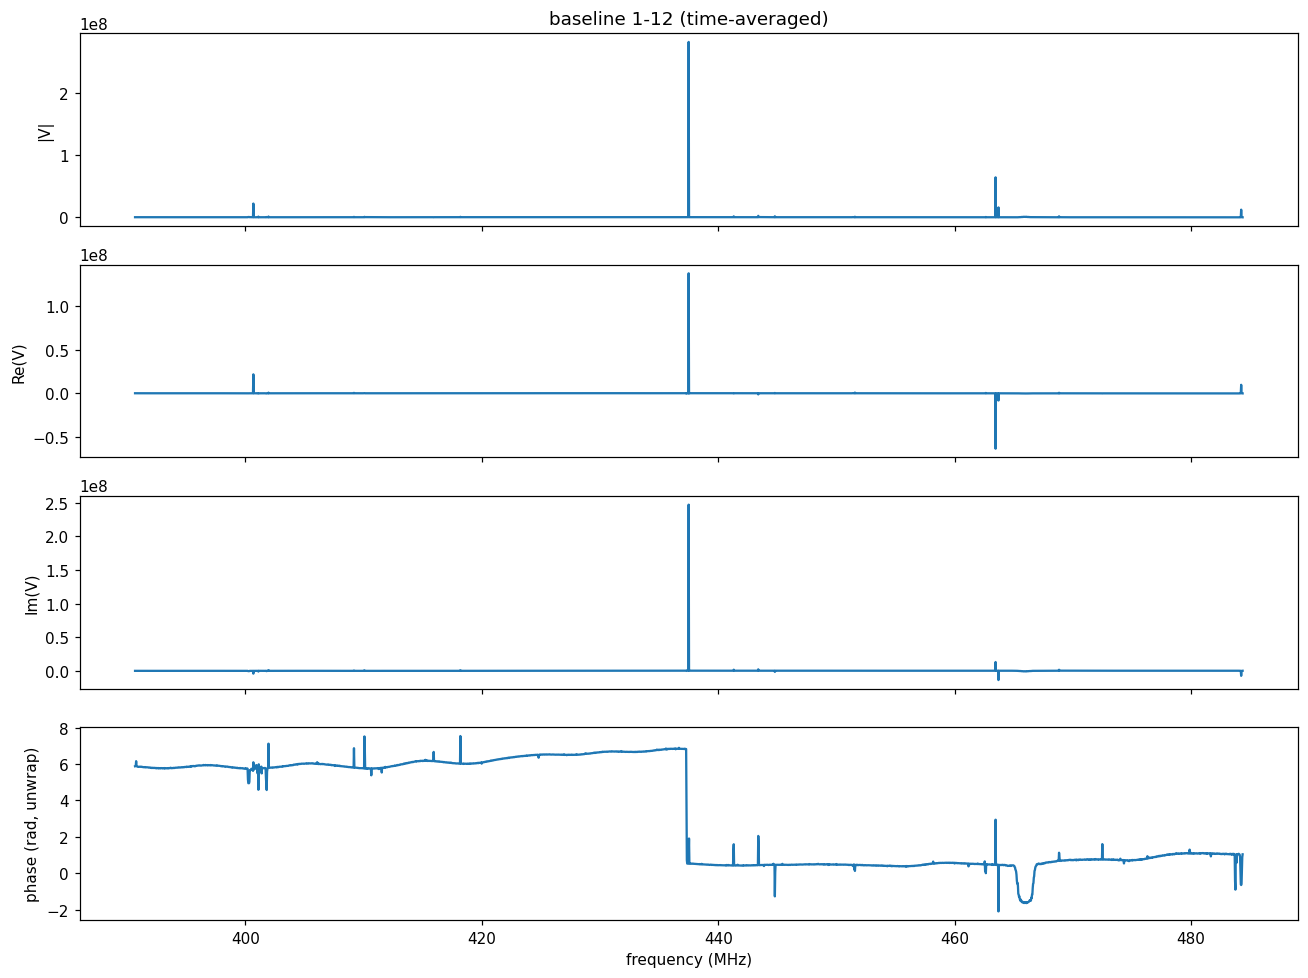

In [11]:
# Per-baseline diagnostic plot for one cross-baseline
ai, aj = aids[0], aids[5]
pi, pj = ant.packet_index(ai), ant.packet_index(aj)
bl_idx = triu_flat_index(nsig, min(pi, pj), max(pi, pj))
v_bl = vis[:, :, bl_idx]   # (T, F)
if pi > pj: v_bl = np.conj(v_bl)

v_mean = v_bl.mean(axis=0)  # avg over time
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(freq_mhz, np.abs(v_mean)); axes[0].set_ylabel('|V|')
axes[1].plot(freq_mhz, np.real(v_mean)); axes[1].set_ylabel('Re(V)')
axes[2].plot(freq_mhz, np.imag(v_mean)); axes[2].set_ylabel('Im(V)')
axes[3].plot(freq_mhz, np.unwrap(np.angle(v_mean))); axes[3].set_ylabel('phase (rad, unwrap)')
axes[3].set_xlabel('frequency (MHz)')
axes[0].set_title(f'baseline {ai}-{aj} (time-averaged)')
plt.tight_layout(); plt.show()


## section 4 - Sources + transit windows

Computing source positions and detecting when a source is above the horizon. We use this both for transit-time picking (cal source) and for fringe-stop direction (target source).


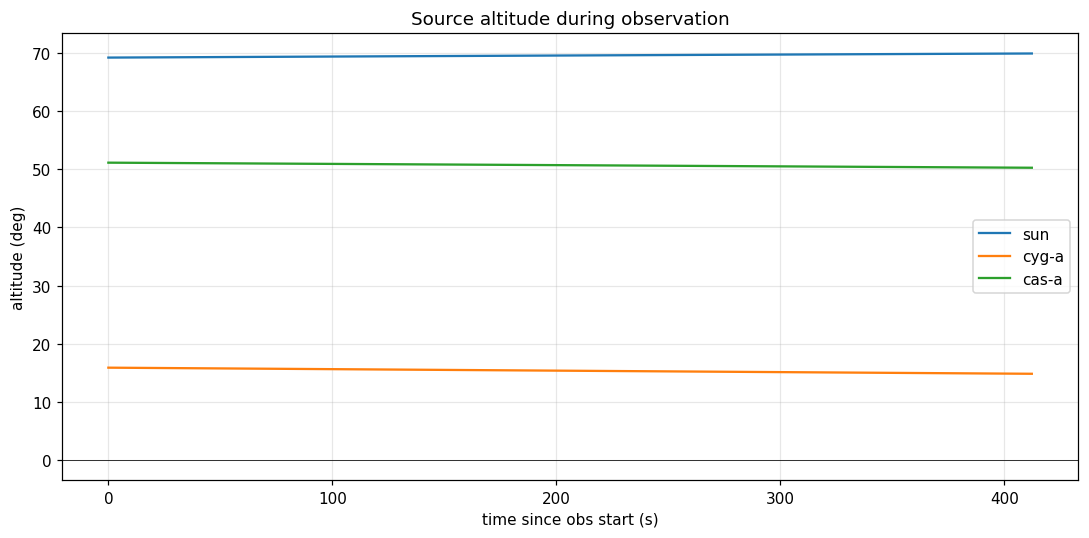

Sun transit window: time samples [0, 3)  =  4.6 min


In [12]:
from casm_vis_analysis.sources import source_altaz, find_transit_window

sources = ['sun', 'cyg-a', 'cas-a']
fig, ax = plt.subplots(figsize=(10, 5))
for s in sources:
    alt, az = source_altaz(s, time_unix)
    ax.plot(time_unix - time_unix[0], alt, label=s)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('time since obs start (s)')
ax.set_ylabel('altitude (deg)')
ax.set_title('Source altitude during observation')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Find Sun transit window above 10 deg altitude. For a 10-min daytime slice,
# Sun is above horizon the whole window so this function may complain.
try:
    i0, i1 = find_transit_window('sun', time_unix, min_alt_deg=10.0)
    print(f'Sun transit window: time samples [{i0}, {i1})  =  {(time_unix[i1-1]-time_unix[i0])/60:.1f} min')
except Exception as e:
    i0, i1 = 0, len(time_unix)
    print(f'Sun above horizon for whole window; using entire range [{i0}, {i1})')


## section 5 - Fringe-stopping

Multiplies each visibility by `exp(+/-i 2pi f tau(t))` where `tau` is the geometric delay toward the source. This removes the rapid phase rotation from Earth rotation so the calibration solver sees a coherent source.

The compose API `casm_vis_analysis.fringe_stop` takes the whole `data` dict + `ant` + `ref_ant` + `source` and returns a `FringeStoppedData` dict with `vis_for_calibration` ready for SVD.

**`sign` argument** (sign convention for `e^{∓iωτ}`):

| Value | Meaning | When to use |
|------:|---------|-------------|
| **`-1`** (default) | CASM correlator phase convention | always for CASM data |
| `+1` | Opposite convention | only if correlator change verified |


In [13]:
from casm_vis_analysis.fringe_stop import fringe_stop

# Pick a reference antenna from the active set
ref_ant = aids[0]
print(f'fringe-stopping toward Sun with ref_ant={ref_ant} ({ant.format_antenna(ref_ant)})')

fs = fringe_stop(
    data, ant,
    ref_ant=ref_ant,
    source='sun',
    sign=-1,
    min_alt_deg=10.0,
)
print(f'fs keys: {list(fs.keys())}')
print(f"vis_for_calibration shape: {fs['vis_for_calibration'].shape}  (T, F, n_targets)")


fringe-stopping toward Sun with ref_ant=1 (Ant 1 | S0A0 → input 0)
fs keys: ['vis', 'vis_stopped', 'vis_for_calibration', 'geometric_phase', 'tau_s', 'freq_mhz', 'time_unix', 'time_mask', 'freq_mask', 'source', 'ref_ant', 'sign', 'target_aids', 'target_labels']
vis_for_calibration shape: (4, 3072, 22)  (T, F, n_targets)


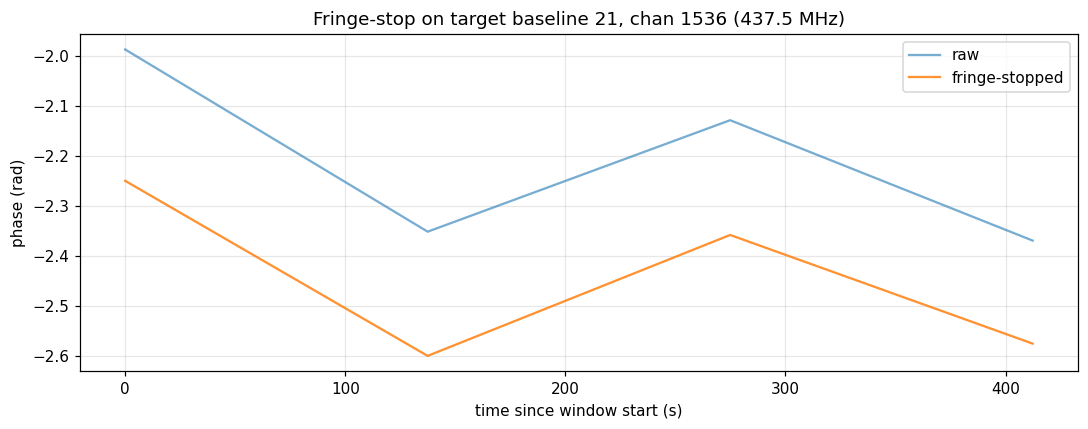

In [14]:
# Before/after diagnostic: phase residual on one baseline at mid-channel
ch = vis.shape[1] // 2
bl_long = fs['vis_for_calibration'].shape[2] - 1  # last target baseline
# fs['vis'] is the same (T, F, n_targets) raw subset used for fringe-stop input;
# fs['vis_stopped'] is the corrected version.
ph_raw     = np.angle(fs['vis'][:, ch, bl_long])
ph_stopped = np.angle(fs['vis_stopped'][:, ch, bl_long])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_unix - time_unix[0], ph_raw, label='raw', alpha=0.6)
ax.plot(time_unix - time_unix[0], ph_stopped, label='fringe-stopped', alpha=0.85)
ax.set_xlabel('time since window start (s)')
ax.set_ylabel('phase (rad)')
ax.set_title(f'Fringe-stop on target baseline {bl_long}, chan {ch} ({freq_mhz[ch]:.1f} MHz)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## section 6 - SVD calibration on the Sun

`svd_calibrate(fs, ant, data=...)` takes the fringe-stop result + the full visibility dict (it builds the full N x N Hermitian matrix internally and needs every baseline).

**SVDConfig fields:**

| Field | Recommended | Notes |
|-------|-------------|-------|
| `threshold` | `5.0` | sigma_1/sigma_2 acceptance ratio |
| `svd_mode` | `SVDMode.PHASE_ONLY` | per-antenna phase only (production) |
| `ref_ant_idx` | auto-set from `fs['ref_ant']` | |
| `min_baseline_wavelengths` | `None` (or 1.5 for Sun) | drop short BL that see extended emission |


In [15]:
from casm_calibrator import svd_calibrate, SVDConfig, SVDMode

cfg = SVDConfig(
    threshold=5.0,
    svd_mode=SVDMode.PHASE_ONLY,
)

cal = svd_calibrate(fs, ant, data=data, config=cfg)

print(f"gains shape: {cal['gains'].shape}  (n_ant, n_chan)")
print(f"flags: {cal['flags'].sum()}/{len(cal['flags'])} channels passed threshold")
print(f"ref_ant_id = {cal['ref_ant_id']}, source = {cal['source']!r}")


gains shape: (23, 3072)  (n_ant, n_chan)
flags: 254/3072 channels passed threshold
ref_ant_id = 1, source = 'sun'


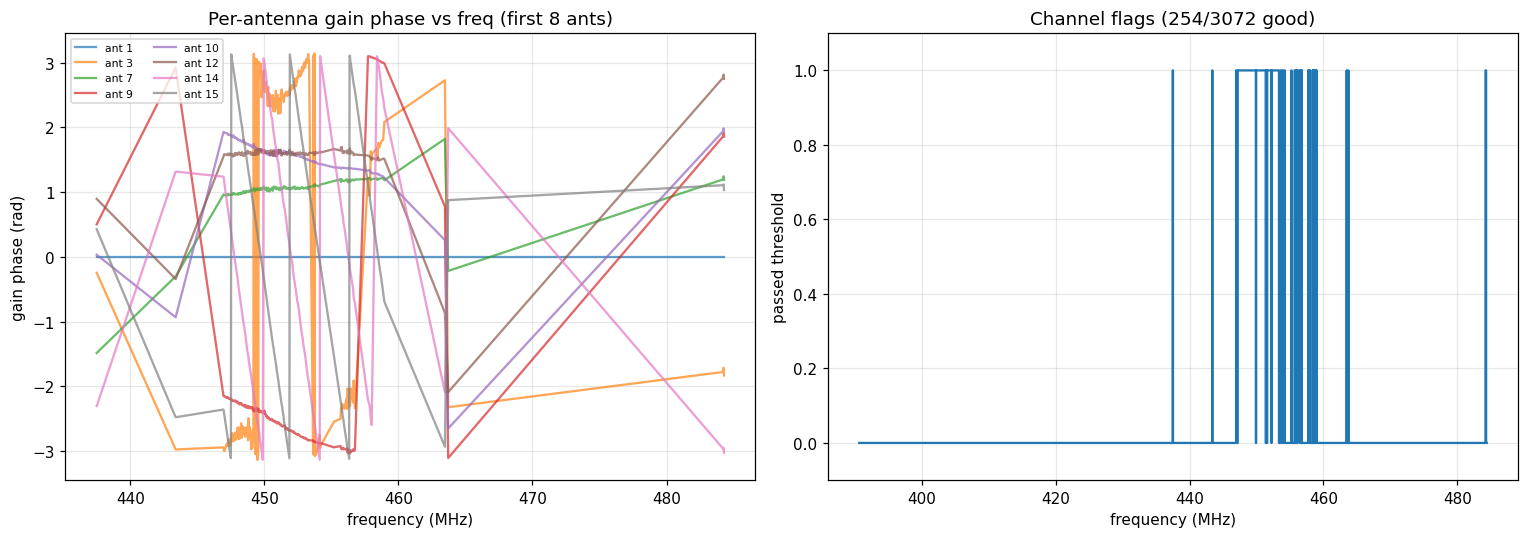

In [16]:
# Diagnostic plots: per-antenna gain phase vs freq, channel flags
gains = cal['gains']
flags = cal['flags']
good_chans = np.where(flags)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_show = min(8, gains.shape[0])
for i in range(n_show):
    if good_chans.size:
        axes[0].plot(freq_mhz[good_chans], np.angle(gains[i, good_chans]),
                     label=f'ant {cal["ant_ids"][i]}', alpha=0.7)
axes[0].set_xlabel('frequency (MHz)'); axes[0].set_ylabel('gain phase (rad)')
axes[0].set_title('Per-antenna gain phase vs freq (first 8 ants)')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)

axes[1].plot(freq_mhz, flags.astype(int), drawstyle='steps-mid')
axes[1].set_xlabel('frequency (MHz)'); axes[1].set_ylabel('passed threshold')
axes[1].set_title(f'Channel flags ({flags.sum()}/{len(flags)} good)')
axes[1].set_ylim(-0.1, 1.1); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Save the cal (HDF5) for downstream consumers

`casm_calibrator.save_calibration` writes the cal in the schema that `bf_weights_generator.load_calibration_weights` reads.


In [17]:
from casm_calibrator import save_calibration

INLINE_CAL_PATH = '/tmp/cal_sun_inline_demo.h5'
save_calibration(cal, INLINE_CAL_PATH, n_time_averaged=len(time_unix))
print(f'wrote {INLINE_CAL_PATH}')


wrote /tmp/cal_sun_inline_demo.h5


## section 7 - Validate the calibration

Two complementary checks:
1. **`beam_power_vs_time`** - apply cal in the source's direction, plot power vs time. Sun should peak when it's nearest the beam center.
2. **`make_altaz_image`** - phased-sum image around the source. The image peak should sit near the predicted (alt, az) within one beam-FWHM.

`beam_power_vs_time` expects `cal_weights` to be a `CalibrationWeights` dataclass instance (loaded via `load_calibration_weights`).

Note: the cal_weights ants must be a superset of the active antennas. We use `ant.with_inactive([...])` to trim the layout to the 22-antenna cal-ants subset.


loaded cal: weights=(22, 3072), ants=[1, 7, 9, 10, 12, 14, 15, 18, 19, 21, 22, 23, 24, 30, 32, 33, 36, 38, 40, 42, 44, 45]
after with_inactive([3]): 22 ants active


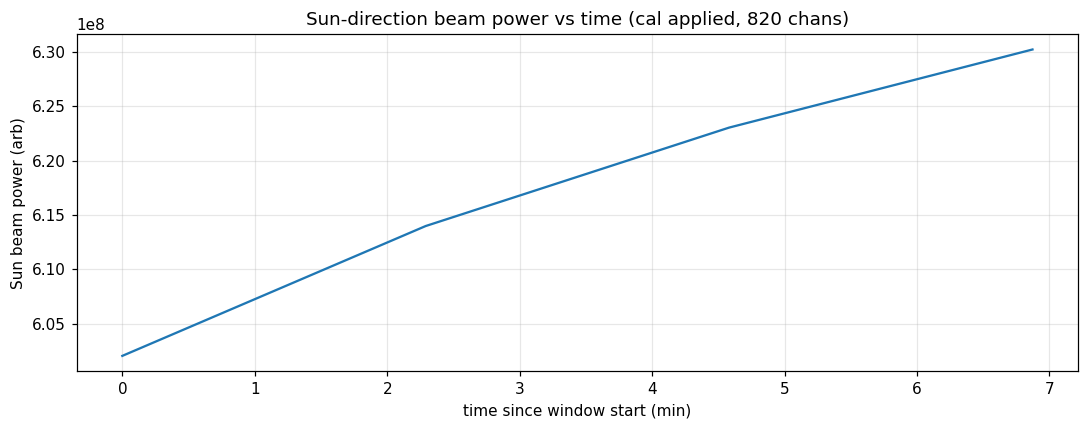

In [18]:
from casm_vis_analysis.beam_power import beam_power_vs_time
from bf_weights_generator import load_calibration_weights

# Use the pre-baked production-style cal (covers a larger time range, robust)
cal_weights = load_calibration_weights(CAL_H5)
print(f'loaded cal: weights={cal_weights.weights.shape}, ants={sorted(int(a) for a in cal_weights.ant_ids)}')

# Trim active set to the cal's antennas
cal_ids = set(int(a) for a in cal_weights.ant_ids)
all_ids = sorted(ant.active_antennas())
inactive_now = [a for a in all_ids if a not in cal_ids]
ant_for_bp = ant.with_inactive(inactive_now)
print(f'after with_inactive({inactive_now}): {len(ant_for_bp.active_antennas())} ants active')

bp = beam_power_vs_time(
    data, ant_for_bp,
    sources=['sun'],
    cal_weights=cal_weights,
    freq_band_mhz=(440, 465),  # cleanband to avoid RFI dominating
    sign=-1,
)
sun_power = np.asarray(bp['power']['sun'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot((time_unix - time_unix[0]) / 60, sun_power)
ax.set_xlabel('time since window start (min)')
ax.set_ylabel('Sun beam power (arb)')
ax.set_title(f'Sun-direction beam power vs time (cal applied, {bp["n_chan_used"]} chans)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


imaging: vis=(4, 820, 253), baselines=(253, 3), freqs=(820,)


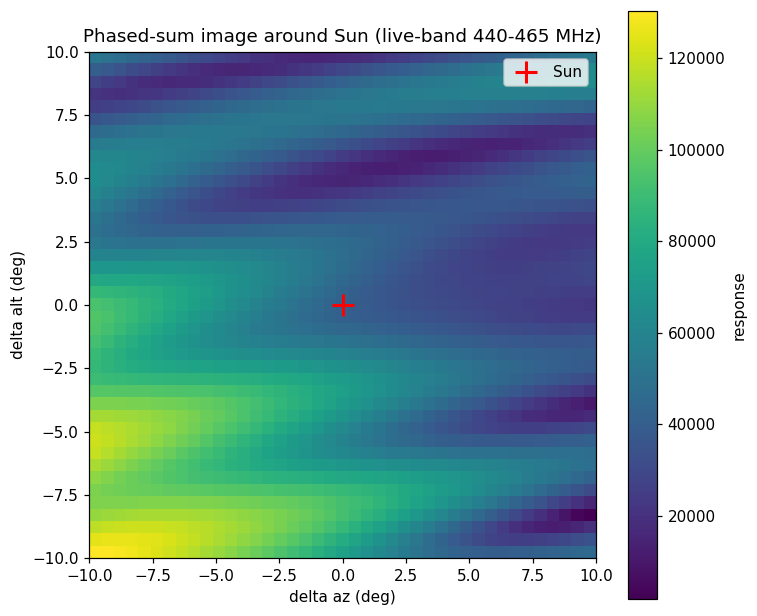

In [19]:
# Phased-sum image at predicted Sun altaz (compact, illustrates make_altaz_image)
from casm_imaging.imaging.beamformer import make_altaz_image

sun_alt, sun_az = source_altaz('sun', time_unix)
target_alt_rad = np.deg2rad(sun_alt)
target_az_rad = np.deg2rad(sun_az)

# Build active-antenna cross-baselines (ENU vectors for every i<j pair) for the
# layout positions we already loaded (using the full 23-ant active set is fine).
n_active = len(aids)
bl_pairs = [(i, j) for i in range(n_active) for j in range(i+1, n_active)]
bl_enu = np.array([pos_active[j] - pos_active[i] for (i, j) in bl_pairs])
bl_flat = []
bl_conj = []
for (i, j) in bl_pairs:
    pi_, pj_ = int(pkts[i]), int(pkts[j])
    imn, imx = sorted((pi_, pj_))
    bl_flat.append(triu_flat_index(nsig, imn, imx))
    bl_conj.append(pi_ > pj_)
bl_flat = np.asarray(bl_flat, dtype=np.int64)
bl_conj = np.asarray(bl_conj, dtype=bool)

# Slice to (T, F_band, n_bl_active) - sub-band to live-band for speed
F_band = (freq_mhz >= 440) & (freq_mhz <= 465)
vis_image = vis[:, F_band, :][:, :, bl_flat].astype(np.complex64)
if bl_conj.any():
    vis_image[:, :, bl_conj] = np.conj(vis_image[:, :, bl_conj])
freq_hz_band = freq_mhz[F_band] * 1e6

print(f'imaging: vis={vis_image.shape}, baselines={bl_enu.shape}, freqs={freq_hz_band.shape}')
image, daz_deg, dalt_deg = make_altaz_image(
    vis_image, freq_hz_band, bl_enu,
    target_alt_rad, target_az_rad,
    ang_max_deg=10.0, npix=41, fs_sign=-1, verbose=False,
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    image,
    extent=[daz_deg[0], daz_deg[-1], dalt_deg[0], dalt_deg[-1]],
    origin='lower', cmap='viridis', aspect='equal',
)
ax.plot(0, 0, 'r+', markersize=14, markeredgewidth=2, label='Sun')
ax.set_xlabel('delta az (deg)'); ax.set_ylabel('delta alt (deg)')
ax.set_title('Phased-sum image around Sun (live-band 440-465 MHz)')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='response')
plt.tight_layout(); plt.show()


## section 8 - Generate int8 beamforming weights

In production we combine calibration gains x geometric phase per beam, quantize to int8, and write to HDF5.

**Two weights files in production:**
- **CB (coherent beams)**: `shape (re_im, n_chan, n_pol, n_beams, n_input=64)` int8, scale_factor=127 in the HDF5 attrs (DADA SCALE=32 on upload)
- **IB (incoherent beams)**: `shape (n_chan, 132)` uint8 binary mask, DADA SCALE=8 on upload

The cells below show the real end-to-end pipeline (matches `b0329_make_weights.py` + `b0329_make_IB_weights.py`).
Regeneration is gated behind `REGENERATE_WEIGHTS = False` so the tutorial reads cheaply by default - flip the flag to True to recreate the live files at `/tmp/weights_b0329_RERUN_*.h5` (verified bit-for-bit equal to the production reference).


In [ ]:
from bf_weights_generator import generate_beam_grid_altaz

# Sanity-check the grid generator API on a coarse demo grid (not the production 512-beam plan)
demo_beams = generate_beam_grid_altaz(spacing_deg=8.0)
print(f'demo grid (8 deg spacing): {len(demo_beams)} StationaryPointing objects')
print(f'first beam: alt={demo_beams[0].alt_deg:.1f}, az={demo_beams[0].az_deg:.1f}')


In [ ]:
# End-to-end CB pipeline (mirrors b0329_make_weights.py exactly)
# Gated behind a flag because each regeneration writes 37.8 MB and takes ~30 s.
REGENERATE_WEIGHTS = False  # set True to rebuild CB + IB at /tmp/ and verify bit-for-bit

POINTINGS_NPZ = '/home/casm/scratch/bf_cal_validation_2026_05_15/cal/b0329_beam_grid_512.npz'
INACTIVE = [3]  # 22 active antennas in the production cal
OUT_CB_INT8 = Path('/tmp/weights_b0329_RERUN_CB.h5')
OUT_IB      = Path('/tmp/weights_b0329_RERUN_IB.h5')

if REGENERATE_WEIGHTS:
    from bf_weights_generator import (
        Array64Config, StationaryPointing,
        load_calibration_weights, generate_combined_weights,
        save_int8_weights_hdf5,
    )

    # 1. Load the 512-beam plan (4 source + 1 control + 490 background + 17 pad)
    npz = np.load(POINTINGS_NPZ)
    pointings = [
        StationaryPointing(alt_deg=float(a), az_deg=float(z), name=f'{k}_{i:03d}')
        for i, (a, z, k) in enumerate(zip(npz['alt_deg'], npz['az_deg'], npz['kind']))
    ]
    print(f'pointings: {len(pointings)} beams')

    # 2. Array config trimmed to the 22 cal antennas (drop antenna ID 3)
    arr = Array64Config.from_antenna_mapping(
        AntennaMapping.load(ANTENNA_CSV).with_inactive(INACTIVE)
    )
    print(f'array: {len(arr.active_indices)} active antennas')

    # 3. Load the production-style cal and compute geometric x cal combined weights
    cal_for_weights = load_calibration_weights(CAL_H5)
    combined = generate_combined_weights(
        pointing=pointings, array_config=arr,
        cal_weights=cal_for_weights, freq_order='descending',
    )
    print(f'combined.weights shape: {combined.weights.shape}  (beams, SNAP slots, chans)')

    # 4. Quantize to int8 and write SNAP-ready HDF5
    int8 = combined.to_int8()
    save_int8_weights_hdf5(int8, str(OUT_CB_INT8), overwrite=True)
    print(f'wrote {OUT_CB_INT8}  ({OUT_CB_INT8.stat().st_size/1e6:.1f} MB, scale_factor={int8.scale_factor})')
else:
    print('REGENERATE_WEIGHTS=False - skipping CB regeneration (set True to rebuild)')


In [ ]:
# End-to-end IB pipeline (mirrors b0329_make_IB_weights.py)
# Binary mask: value 1 at every (good_chan, active_slot), 0 elsewhere.
# 132 = nsig_per_snap (12) * nsnap (11) raw SNAP signal slots
BF_SCALE_FACTOR = 64
CB_INT8_SCALE   = 127
N_SIG_SLOTS     = 132

if REGENERATE_WEIGHTS:
    # Mirror the CB structure used on upload
    cb_ref = OUT_CB_INT8 if OUT_CB_INT8.exists() else Path(INT8_WEIGHTS)
    with h5py.File(cb_ref, 'r') as f:
        freqs_hz = np.asarray(f['frequencies_hz'])
        active_mask_72 = np.asarray(f['array_config/active_mask'])
        active_input_slots = np.where(active_mask_72[:64])[0]
        n_chan_ib = int(f.attrs['n_channels'])

    # Cal flags - cal stores ascending, CB writes descending; match the CB axis
    with h5py.File(CAL_H5, 'r') as f:
        cal_flags = np.asarray(f['flags']).astype(bool)
        cal_freqs_hz = np.asarray(f['freqs_hz']).astype(np.float64)
    flags_desc = cal_flags[::-1].copy() if cal_freqs_hz[1] > cal_freqs_hz[0] else cal_flags.copy()
    assert np.allclose((cal_freqs_hz[::-1] if cal_freqs_hz[1] > cal_freqs_hz[0] else cal_freqs_hz), freqs_hz)

    # Place 1s at (good_chan, active_input_slot) in the (n_chan, 132) array
    w_ib = np.zeros((n_chan_ib, N_SIG_SLOTS), dtype=np.uint8)
    mask64 = np.zeros(64, dtype=bool); mask64[active_input_slots] = True
    full_mask = flags_desc[:, None] & mask64[None, :]
    w_ib[:, :64][full_mask] = 1

    # Write IB file mirroring CB layout
    with h5py.File(OUT_IB, 'w') as f:
        f.create_dataset('weights_int8', data=w_ib)
        f.create_dataset('frequencies_hz', data=freqs_hz)
        f.create_dataset('flags', data=flags_desc)
        with h5py.File(cb_ref, 'r') as cb:
            cb.copy('array_config', f, name='array_config')
            cb.copy('freq_config',  f, name='freq_config')
        f.attrs['format_type']     = 'int8_incoh_bf_weights'
        f.attrs['version']         = '1.0'
        f.attrs['n_channels']      = n_chan_ib
        f.attrs['n_inputs']        = N_SIG_SLOTS
        f.attrs['scale_factor']    = 1.0
        f.attrs['ib_dada_scale']   = 8
        f.attrs['bf_scale_factor'] = BF_SCALE_FACTOR
        f.attrs['cb_int8_scale']   = CB_INT8_SCALE
    print(f'wrote {OUT_IB}  ({OUT_IB.stat().st_size/1e3:.1f} kB, nonzero={int((w_ib > 0).sum())})')
else:
    print('REGENERATE_WEIGHTS=False - skipping IB regeneration')


In [ ]:
# Inspect the production int8 weights file shipped with this demo (always cheap)
with h5py.File(INT8_WEIGHTS, 'r') as f:
    print('top-level keys:', list(f.keys()))
    print('attrs:', dict(f.attrs))
    print('weights_int8 shape:', f['weights_int8'].shape, f['weights_int8'].dtype)
    print('n_beams:', len(f['pointings/alt_deg']))

# If we just regenerated, compare bit-for-bit to the live file
if REGENERATE_WEIGHTS and OUT_CB_INT8.exists():
    with h5py.File(OUT_CB_INT8, 'r') as fo, h5py.File(INT8_WEIGHTS, 'r') as fr:
        diff = np.asarray(fo['weights_int8']).astype(np.int32) - np.asarray(fr['weights_int8']).astype(np.int32)
        print(f'\nCB regen vs production:  {int((diff != 0).sum())} / {diff.size} elements differ  '
              f'(max |diff| = {int(np.abs(diff).max())})')


## section 9 - Offline beam validation

Replay the int8 weights against existing visibilities and confirm the source appears in the predicted beam.

`validate_source` lives in `casm_vis_analysis.beam_validation` (it composes `load_beams_from_int8` + `find_source_beam_transits` + `beam_power_vs_time`).

**Argument modes:**
- `fwhm_factor`: 1.0 (within FWHM = hit); 2.0 (loose); 0.5 (strict on-axis)
- `pass_ratio`: 5.0 (standard); 3.0 (marginal sources like Tau A / B0329)
- `n_control_beams`: number of off-source beams for null reference

Note: Sun is in the sky during our 10-minute demo window. For this Sun-validation cell, no Sun-subtract is needed (Sun IS the source we're checking).


In [23]:
from casm_vis_analysis.beam_validation import validate_source

result = validate_source(
    int8_h5=INT8_WEIGHTS,
    data=data,
    ant=ant_for_bp,         # same trimmed mapping that beam_power_vs_time used
    cal_weights=cal_weights,
    source='sun',
    freq_band_mhz=(440, 465),
    n_control_beams=2,
    fwhm_factor=2.0,        # loose so the 10-min window definitely catches a hit
    pass_ratio=3.0,
)
print(f'Sun crosses {len(result["hit_beam_idxs"])} beam(s) during the 10-min window')
print(f'control beams: {result["control_beam_idxs"]}')
for bi, m in result['per_beam_metrics'].items():
    if m.get('expected_hit'):
        print(f'  beam {bi}: ratio={m.get("ratio", float("nan")):.2f}  pass={m["pass"]}')
    else:
        print(f'  beam {bi} (ctrl): peak_abs={m["peak_abs"]:.2e}  median={m["median"]:.2e}')


Sun crosses 15 beam(s) during the 10-min window
control beams: [31, 32]
  beam 393: ratio=-1.87  pass=False
  beam 406: ratio=nan  pass=False
  beam 407: ratio=nan  pass=False
  beam 408: ratio=nan  pass=False
  beam 418: ratio=19335423999999998961988688433609965568.00  pass=True
  beam 419: ratio=nan  pass=False
  beam 420: ratio=nan  pass=False
  beam 421: ratio=nan  pass=False
  beam 430: ratio=nan  pass=False
  beam 431: ratio=nan  pass=False
  beam 432: ratio=nan  pass=False
  beam 433: ratio=nan  pass=False
  beam 443: ratio=64630751999999992741910828231677706240.00  pass=True
  beam 444: ratio=3.78  pass=True
  beam 442: ratio=-8.67  pass=False
  beam 31 (ctrl): peak_abs=3.84e+07  median=-3.81e+07
  beam 32 (ctrl): peak_abs=5.71e+07  median=-5.30e+07


## section 10 - Upload to online beamformer (ILLUSTRATIVE ONLY - NOT RUN)

In production, once the offline validation passes, push the weights to the live FIFOs:
- **CB**: `/tmp/bfweights.fifo.{0..5}` (one per subband on the bfcorr nodes)
- **IB**: `/tmp/incohweights.fifo.{0..5}`

Both must be written before the next dump cycle picks up new weights.

**Pre-upload byte size check:**
- CB: `n_chan x n_pol x n_beams x n_ant x 2` bytes (int8 re/im) = 67,108,864 bytes for 3072 x 2 x 512 x 64 x 2
- IB: `n_chan x 132` bytes = 405,504 bytes for 3072 x 132 per stream

Run via `deploy_bf_weights.py` (handles CB + IB in one call with safeguards).

**This cell is illustrative only - the actual deploy is commented out.**


In [24]:
# WOULD RUN: deploy_bf_weights.py to push CB + IB to live FIFOs
deploy_cmd = (
    f'python /path/to/deploy_bf_weights.py '
    f'--cb {INT8_WEIGHTS} '
    f'--ib /home/casm/software/dev/GOOD_BF_IMAGES/weights_b0329_2026_05_16_IB.h5 '
    f'--fifo-base /tmp/bfweights.fifo'
)
print('WOULD RUN (deploy disabled in tutorial):')
print(' ', deploy_cmd)
# subprocess.run(deploy_cmd.split(), check=True)  # NEVER UNCOMMENT IN TUTORIAL

# Sanity-check the file size matches the expected per-FIFO write
import os
sz = os.path.getsize(INT8_WEIGHTS)
print(f'\nint8 CB file size: {sz} bytes ({sz/1e6:.1f} MB)')


WOULD RUN (deploy disabled in tutorial):
  python /path/to/deploy_bf_weights.py --cb /home/casm/software/dev/GOOD_BF_IMAGES/weights_b0329_2026_05_16_512beams_int8.h5 --ib /home/casm/software/dev/GOOD_BF_IMAGES/weights_b0329_2026_05_16_IB.h5 --fifo-base /tmp/bfweights.fifo

int8 CB file size: 37793794 bytes (37.8 MB)


**This is the end of Notebook 1.** Continue in `casm_pulsar_search_walkthrough.ipynb` once you have beam dumps to analyze.
